# A caller-owned multi-SKU component loop

Build one small inventory workflow from Pyforia components for five synthetic SKUs. The caller advances each complete daily demand vector, reviews state, requests eligible orders, places them in the pipeline, and records its own state snapshots.

## 1. Choose the supported workflow

Pyforia supports two complementary styles. Use `SimulationEngine` for a complete canonical run. Use components when a caller deliberately needs control of the loop. This notebook demonstrates that supported component style; it is not an internal workaround.

The caller owns loop control, state recording, input provenance, and any event-like artifact. The history below is therefore a teaching record, not Pyforia's validated canonical event ledger.

In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from pyforia import InventoryStateDataFrame, OrderUpToPolicy, SimulationEngine
from pyforia.evaluation import InventoryEvaluator, avg_on_hand, fill_rate, order_units
from pyforia.utils import update_inventory_with_orders


In [2]:
# Shared coordinates for this five-SKU daily scenario.
opening_date = pd.Timestamp('2026-01-05')
period_frequency = 'D'

# Orders take two days to arrive; stock is reviewed every two days.
lead_time = 2
review_period = 2
n_periods = 8


### Declare a complete synthetic SKU-by-period grid

The scenario has five named synthetic items, eight daily periods, observed opening stock, and one direct cumulative target per item. The 40 rows are a complete teaching grid, not a bundled or production full dataset. Pyforia does not infer missing demand, opening stock, or targets.

In [3]:
# Values are explicit synthetic scenario inputs, not observations or forecasts.
skus = ['tea_250g', 'coffee_250g', 'pasta_500g', 'cereal_400g', 'soup_400g']
opening_stock = pd.DataFrame({
    'unique_id': skus,
    'observed_on_hand': [20.0, 22.0, 18.0, 19.0, 16.0],
})
demand_values = {
    'tea_250g': [6.0, 8.0, 5.0, 7.0, 6.0, 4.0, 7.0, 5.0],
    'coffee_250g': [4.0, 5.0, 6.0, 5.0, 7.0, 6.0, 4.0, 5.0],
    'pasta_500g': [5.0, 4.0, 6.0, 5.0, 4.0, 6.0, 5.0, 4.0],
    'cereal_400g': [3.0, 5.0, 4.0, 6.0, 5.0, 3.0, 4.0, 6.0],
    'soup_400g': [2.0, 3.0, 4.0, 3.0, 5.0, 4.0, 3.0, 2.0],
}

In [4]:
# A transparent wide-to-long reshape makes the full dense input visible.
demand_wide = pd.DataFrame(
    demand_values,
    index=pd.date_range(opening_date + pd.Timedelta(days=1), periods=n_periods, freq=period_frequency),
).rename_axis('date').reset_index()
demand = demand_wide.melt(id_vars='date', var_name='unique_id', value_name='y')
demand['period'] = demand.groupby('unique_id').cumcount()
demand = demand[['unique_id', 'period', 'date', 'y']].sort_values(['period', 'unique_id']).reset_index(drop=True)

# One direct cumulative target per SKU for the four-day protection horizon.
target = pd.DataFrame({
    'unique_id': skus,
    'protection_target': [30.0, 31.0, 27.0, 28.0, 22.0],
    'target_end_date': [opening_date + pd.Timedelta(days=lead_time + review_period)] * len(skus),
})
target

,unique_id,protection_target,target_end_date
0,tea_250g,30.0,2026-01-09
1,coffee_250g,31.0,2026-01-09
2,pasta_500g,27.0,2026-01-09
3,cereal_400g,28.0,2026-01-09
4,soup_400g,22.0,2026-01-09


In [5]:
# Opening stock is a declared scenario input, not an estimate from demand.
opening_stock


,unique_id,observed_on_hand
0,tea_250g,20.0
1,coffee_250g,22.0
2,pasta_500g,18.0
3,cereal_400g,19.0
4,soup_400g,16.0


In [6]:
# Caller-provided four-day cumulative targets, one per SKU.
target


,unique_id,protection_target,target_end_date
0,tea_250g,30.0,2026-01-09
1,coffee_250g,31.0,2026-01-09
2,pasta_500g,27.0,2026-01-09
3,cereal_400g,28.0,2026-01-09
4,soup_400g,22.0,2026-01-09


In [7]:
# The 40 rows are a complete teaching grid: five SKUs over eight daily periods.
assert len(demand) == len(skus) * n_periods
assert demand.groupby('period')['unique_id'].nunique().eq(len(skus)).all()
assert demand[['unique_id', 'period']].duplicated().sum() == 0
assert demand['date'].min() == opening_date + pd.Timedelta(days=1)

demand.head(15)


,unique_id,period,date,y
0,cereal_400g,0,2026-01-06,3.0
1,coffee_250g,0,2026-01-06,4.0
2,pasta_500g,0,2026-01-06,5.0
3,soup_400g,0,2026-01-06,2.0
4,tea_250g,0,2026-01-06,6.0
5,cereal_400g,1,2026-01-07,5.0
6,coffee_250g,1,2026-01-07,5.0
7,pasta_500g,1,2026-01-07,4.0
8,soup_400g,1,2026-01-07,3.0
9,tea_250g,1,2026-01-07,8.0


### See every declared demand series

This two-row, four-column grid shows each SKU's complete daily demand series before inventory decisions. A sixth panel gives the portfolio total; every panel uses lines and markers only, with no area shading.

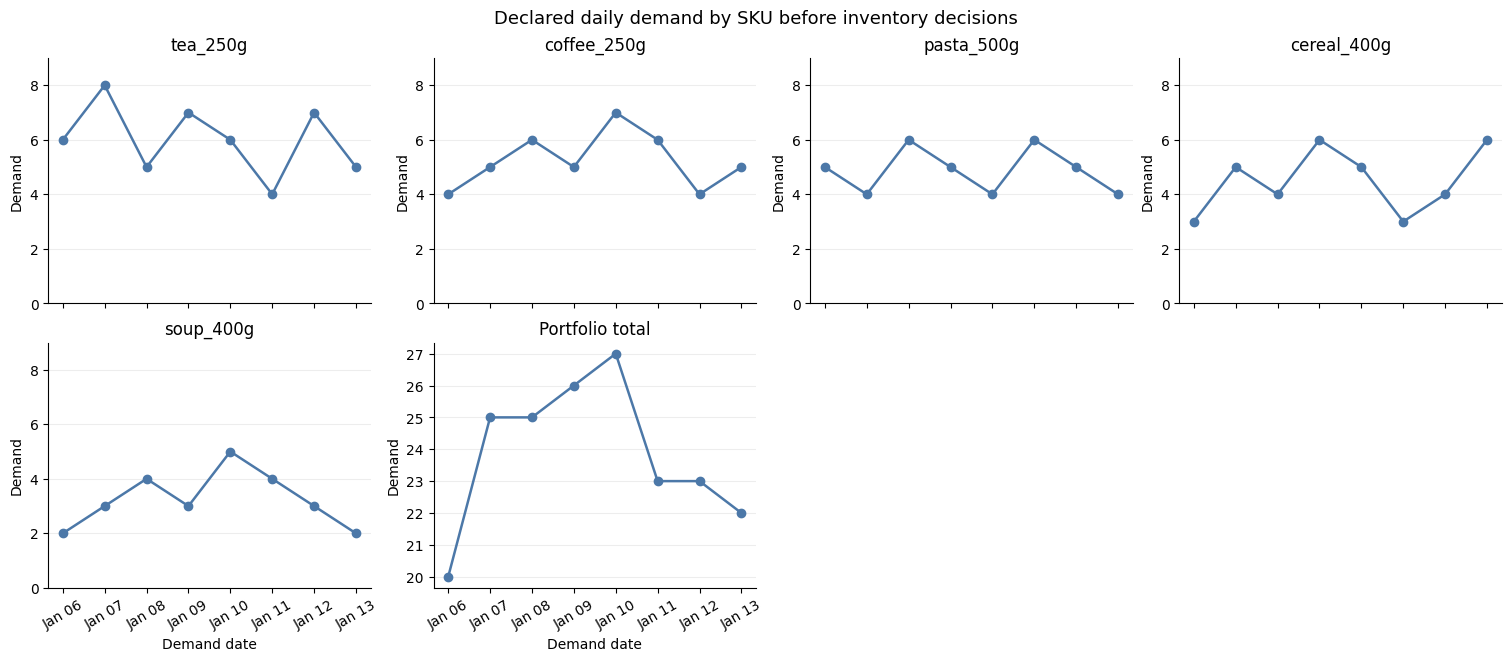

In [8]:
portfolio_demand = demand.groupby('date', as_index=False)['y'].sum()
demand_series = [(sku, demand.loc[demand['unique_id'].eq(sku), ['date', 'y']]) for sku in skus]
demand_series.append(('Portfolio total', portfolio_demand))
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), sharex=True, layout='constrained')
for axis, (label, series) in zip(axes.flat, demand_series):
    axis.plot(series['date'], series['y'], color='#4C78A8', marker='o', linewidth=1.8)
    axis.set(title=label, ylabel='Demand')
    if label != 'Portfolio total':
        axis.set_ylim(0, demand['y'].max() + 1)
    axis.grid(axis='y', alpha=0.22)
    axis.spines[['top', 'right']].set_visible(False)
for axis in axes.flat[len(demand_series):]:
    axis.set_visible(False)
for axis in axes[1]:
    axis.set_xlabel('Demand date')
    axis.xaxis.set_major_locator(mdates.DayLocator())
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    axis.tick_params(axis='x', labelrotation=30)
fig.suptitle('Declared daily demand by SKU before inventory decisions', fontsize=13)
plt.show()

## 2. Fit one explicit policy across the SKU set

`OrderUpToPolicy` uses a direct four-day cumulative target for each SKU: two lead-time days plus two review-cycle days. The targets are caller-provided, dated, probability-labelled, and explicitly external; this notebook does not fit a forecast or create uncertainty heuristics.

In [9]:
policy = OrderUpToPolicy(
    lead_time=lead_time, review_period=review_period, service_level=0.95, allow_backorders=False,
).fit(
    target,
    target_column='protection_target',
    target_probability=0.95,
    protection_horizon=lead_time + review_period,
    target_source='external_direct',
    forecast_origin=opening_date,
    forecast_frequency=period_frequency,
    target_end_date_column='target_end_date',
)
print('Fitted per-SKU targets')
print(policy.get_target_levels().to_string(index=False))
print('\nShared target metadata')
print(pd.DataFrame([policy.get_target_metadata()]).to_string(index=False))

Fitted per-SKU targets
  unique_id  target_level
   tea_250g          30.0
coffee_250g          31.0
 pasta_500g          27.0
cereal_400g          28.0
  soup_400g          22.0

Shared target metadata
                 representation  target_probability  protection_horizon   target_source     forecast_origin forecast_frequency     target_end_date
direct_protection_period_target                0.95                   4 external_direct 2026-01-05T00:00:00                  D 2026-01-09T00:00:00


### Initialize caller-owned inventory

The observed opening state has zero backlog and an empty two-slot pipeline for each SKU. Each component call returns a new state snapshot, which the caller keeps under its own control.

In [10]:
# The caller owns this state; every component call below returns a new snapshot.
manual_state = InventoryStateDataFrame(
    skus, max_lead_time=lead_time, allow_backorders=False
).initialize_from_observed(
    opening_stock, on_hand_column='observed_on_hand', start_date=opening_date
)
manual_state


InventoryStateDataFrame(n_skus=5, total_on_hand=95, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

In [11]:
print('Explicit opening state')
print(manual_state.get_dataframe()[['unique_id', 'on_hand', 'backorders', 'in_transit', 'period', 'date']].to_string(index=False))


Explicit opening state
  unique_id  on_hand  backorders in_transit  period       date
   tea_250g     20.0         0.0 [0.0, 0.0]     0.0 2026-01-05
coffee_250g     22.0         0.0 [0.0, 0.0]     0.0 2026-01-05
 pasta_500g     18.0         0.0 [0.0, 0.0]     0.0 2026-01-05
cereal_400g     19.0         0.0 [0.0, 0.0]     0.0 2026-01-05
  soup_400g     16.0         0.0 [0.0, 0.0]     0.0 2026-01-05


## 3. Run the visible component loop

For each complete daily demand vector, the caller controls this sequence:

```text
process_demand
  -> inspect is_review_period
  -> policy.predict when eligible
  -> update_inventory_with_orders
  -> append caller-owned state snapshot
```

`process_demand` advances time, receives due stock, then serves that date's full SKU vector. A policy prediction is eligible only after the caller inspects the advanced state's review flag. Order placement changes pipeline and inventory position, not current on-hand stock.

In [12]:
history_rows = []
order_rows = []

for demand_period in range(n_periods):
    daily_demand = demand.loc[demand['period'].eq(demand_period), ['unique_id', 'date', 'y']]
    # Demand contains all five SKUs for one explicit date.
    manual_state = manual_state.process_demand(
        daily_demand, review_period=review_period, period_frequency=period_frequency
    )
    on_hand_after_demand = manual_state.get_dataframe().set_index('unique_id')['on_hand']

    # Review eligibility belongs to the advanced state, not to the policy.
    if bool(manual_state.get_dataframe()['is_review_period'].iloc[0]):
        decision = policy.predict(
            manual_state, current_period=int(manual_state.get_dataframe()['period'].iloc[0])
        )
        order_rows.extend(decision.get_dataframe().to_dict('records'))
        # Placement validates timing and changes pipeline, not physical stock.
        manual_state = update_inventory_with_orders(manual_state, decision, policy=policy)

    state_view = manual_state.inventory_position()[[
        'unique_id', 'period', 'latest_received', 'latest_order', 'latest_fulfilled',
        'latest_shortage', 'on_hand', 'backorders', 'total_in_transit',
        'inventory_position', 'is_review_period',
]].copy()
    # This merge is the caller's record; it is not a canonical event artifact.
    snapshot = daily_demand.merge(state_view, on='unique_id', validate='one_to_one').rename(columns={
        'y': 'demand', 'latest_received': 'received', 'latest_order': 'ordered',
        'latest_fulfilled': 'fulfilled', 'latest_shortage': 'shortage',
        'total_in_transit': 'pipeline',
    })
    snapshot['on_hand_after_demand'] = snapshot['unique_id'].map(on_hand_after_demand)
    history_rows.extend(snapshot.to_dict('records'))

manual_history = pd.DataFrame(history_rows).sort_values(['period', 'unique_id']).reset_index(drop=True)
manual_orders = pd.DataFrame(order_rows).sort_values(['order_period', 'unique_id']).reset_index(drop=True)

### Inspect caller-owned snapshots and requests

Each row is one SKU after one daily transition. The rows reveal the complete state shape used by a multi-SKU caller while remaining distinct from the engine's canonical event ledger.

In [13]:
history_columns = [
    'period', 'date', 'unique_id', 'demand', 'received', 'ordered', 'on_hand',
    'pipeline', 'inventory_position', 'is_review_period',
]
print('Caller-owned state snapshots (first 15 of 40 rows)')
print(manual_history[history_columns].head(15).round(2).to_string(index=False))


Caller-owned state snapshots (first 15 of 40 rows)
 period       date   unique_id  demand  received  ordered  on_hand  pipeline  inventory_position  is_review_period
    1.0 2026-01-06 cereal_400g     3.0       0.0      0.0     16.0       0.0                16.0             False
    1.0 2026-01-06 coffee_250g     4.0       0.0      0.0     18.0       0.0                18.0             False
    1.0 2026-01-06  pasta_500g     5.0       0.0      0.0     13.0       0.0                13.0             False
    1.0 2026-01-06   soup_400g     2.0       0.0      0.0     14.0       0.0                14.0             False
    1.0 2026-01-06    tea_250g     6.0       0.0      0.0     14.0       0.0                14.0             False
    2.0 2026-01-07 cereal_400g     5.0       0.0     17.0     11.0      17.0                28.0              True
    2.0 2026-01-07 coffee_250g     5.0       0.0     18.0     13.0      18.0                31.0              True
    2.0 2026-01-07  pasta_500

In [14]:
print('Policy order requests (first 10 rows)')
print(manual_orders[['unique_id', 'order_period', 'expected_delivery_period', 'order_quantity']].head(10).round(2).to_string(index=False))

print('\nPositive order requests by SKU')
print(manual_orders.loc[manual_orders['order_quantity'] > 0, 'unique_id'].value_counts().to_string())


Policy order requests (first 10 rows)
  unique_id  order_period  expected_delivery_period  order_quantity
cereal_400g             2                         4            17.0
coffee_250g             2                         4            18.0
 pasta_500g             2                         4            18.0
  soup_400g             2                         4            11.0
   tea_250g             2                         4            24.0
cereal_400g             4                         6            10.0
coffee_250g             4                         6            11.0
 pasta_500g             4                         6            11.0
  soup_400g             4                         6             7.0
   tea_250g             4                         6            12.0

Positive order requests by SKU
unique_id
cereal_400g    4
coffee_250g    4
pasta_500g     4
soup_400g      4
tea_250g       4


## 4. Summarize the caller-owned record

These totals are caller-computed descriptions of the snapshots, not evaluator outputs or a performance claim. They make each item's demand, orders, ending stock, and pipeline visible before the engine comparison.

In [15]:
caller_summary = manual_history.groupby('unique_id', as_index=False).agg(
    total_demand=('demand', 'sum'),
    total_received=('received', 'sum'),
    total_ordered=('ordered', 'sum'),
    total_shortage=('shortage', 'sum'),
    ending_on_hand=('on_hand', 'last'),
    ending_pipeline=('pipeline', 'last'),
).sort_values('unique_id')
print(caller_summary.round(2).to_string(index=False))
assert caller_summary['total_shortage'].eq(0.0).all()

  unique_id  total_demand  total_received  total_ordered  total_shortage  ending_on_hand  ending_pipeline
cereal_400g          36.0            35.0           45.0             0.0            18.0             10.0
coffee_250g          42.0            42.0           51.0             0.0            22.0              9.0
 pasta_500g          39.0            39.0           48.0             0.0            18.0              9.0
  soup_400g          26.0            27.0           32.0             0.0            17.0              5.0
   tea_250g          48.0            46.0           58.0             0.0            18.0             12.0


### Keep the caller-owned portfolio totals inspectable

This compact table sums the five caller-owned snapshots at each date. It remains descriptive evidence only; the canonical aggregate visual follows the equivalent engine run.

In [16]:
portfolio_history = manual_history.groupby(['period', 'date'], as_index=False).agg(
    demand=('demand', 'sum'), fulfilled=('fulfilled', 'sum'), shortage=('shortage', 'sum'),
    received=('received', 'sum'), ordered=('ordered', 'sum'),
    on_hand=('on_hand', 'sum'), pipeline=('pipeline', 'sum'),
    inventory_position=('inventory_position', 'sum'),
)
print('Caller-owned portfolio totals by daily snapshot')
print(portfolio_history.round(2).to_string(index=False))

Caller-owned portfolio totals by daily snapshot
 period       date  demand  fulfilled  shortage  received  ordered  on_hand  pipeline  inventory_position
    1.0 2026-01-06    20.0       20.0       0.0       0.0      0.0     75.0       0.0                75.0
    2.0 2026-01-07    25.0       25.0       0.0       0.0     88.0     50.0      88.0               138.0
    3.0 2026-01-08    25.0       25.0       0.0       0.0      0.0     25.0      88.0               113.0
    4.0 2026-01-09    26.0       26.0       0.0      88.0     51.0     87.0      51.0               138.0
    5.0 2026-01-10    27.0       27.0       0.0       0.0      0.0     60.0      51.0               111.0
    6.0 2026-01-11    23.0       23.0       0.0      51.0     50.0     88.0      50.0               138.0
    7.0 2026-01-12    23.0       23.0       0.0       0.0      0.0     65.0      50.0               115.0
    8.0 2026-01-13    22.0       22.0       0.0      50.0     45.0     93.0      45.0               138.

### Keep the per-SKU end state compact

The caller-owned terminal-state table remains useful for inspection, but it does not try to visualize in-transit timing. The engine-owned aggregate visual below makes order, receipt, and unreceived-order timing explicit.

In [17]:
manual_terminal_view = manual_history.sort_values(['unique_id', 'period']).groupby('unique_id', as_index=False).tail(1)
print(manual_terminal_view[[
    'unique_id', 'on_hand', 'pipeline', 'inventory_position', 'backorders', 'date'
]].round(2).to_string(index=False))

  unique_id  on_hand  pipeline  inventory_position  backorders       date
cereal_400g     18.0      10.0                28.0         0.0 2026-01-13
coffee_250g     22.0       9.0                31.0         0.0 2026-01-13
 pasta_500g     18.0       9.0                27.0         0.0 2026-01-13
  soup_400g     17.0       5.0                22.0         0.0 2026-01-13
   tea_250g     18.0      12.0                30.0         0.0 2026-01-13


### Make the component timing executable

Every positive order must have expected delivery exactly two periods later. For arrivals inside the eight-period horizon, the matching caller-owned receipt must equal the earlier order quantity. The saved pre-order on-hand value verifies that placement itself did not alter physical stock.

In [18]:
positive_orders = manual_orders.loc[manual_orders['order_quantity'].gt(0)].copy()
print('Positive SKU orders (first 10)')
print(positive_orders[['unique_id', 'order_period', 'expected_delivery_period', 'order_quantity']].head(10).round(2).to_string(index=False))

assert (positive_orders['expected_delivery_period'] == positive_orders['order_period'] + lead_time).all()
assert (positive_orders['expected_delivery_period'] > positive_orders['order_period']).all()

review_snapshots = manual_history.loc[manual_history['ordered'].gt(0)]
assert (review_snapshots['on_hand'] == review_snapshots['on_hand_after_demand']).all()

arrivals_in_horizon = positive_orders.loc[positive_orders['expected_delivery_period'].le(n_periods)]
arrival_snapshots = manual_history.merge(
    arrivals_in_horizon[['unique_id', 'expected_delivery_period', 'order_quantity']],
    left_on=['unique_id', 'period'], right_on=['unique_id', 'expected_delivery_period'],
    validate='one_to_one',
)
assert (arrival_snapshots['received'] == arrival_snapshots['order_quantity']).all()
print(f'\nValidated {len(positive_orders)} positive SKU orders and {len(arrivals_in_horizon)} in-horizon receipts.')


Positive SKU orders (first 10)
  unique_id  order_period  expected_delivery_period  order_quantity
cereal_400g             2                         4            17.0
coffee_250g             2                         4            18.0
 pasta_500g             2                         4            18.0
  soup_400g             2                         4            11.0
   tea_250g             2                         4            24.0
cereal_400g             4                         6            10.0
coffee_250g             4                         6            11.0
 pasta_500g             4                         6            11.0
  soup_400g             4                         6             7.0
   tea_250g             4                         6            12.0

Validated 20 positive SKU orders and 15 in-horizon receipts.


## 5. Compare with the equivalent engine run

The component loop is supported, but it does not recreate complete-run preflight, canonical events, callback phases, policy-schedule validation, constraints/audit orchestration, evaluator-ready outputs, or a run manifest. This engine case has no constraints or callbacks and no opening decision, so its physical transitions match the loop above.

In [19]:
engine_opening_state = InventoryStateDataFrame(
    skus, max_lead_time=lead_time, allow_backorders=False
).initialize_from_observed(
    opening_stock, on_hand_column='observed_on_hand', start_date=opening_date
)
engine_result = SimulationEngine().run(
    policy=policy, demand_source=demand, inventory=engine_opening_state, n_periods=n_periods,
    period_frequency=period_frequency, initial_decision='none',
    warmup_periods=0, scoring_periods=n_periods, settlement_periods=0,
    order_during_settlement=False, demand_source_name='declared_five_sku_component_loop',
    random_seed=None,
)


In [20]:
# The engine owns this state; the caller-owned `manual_state` above is unchanged.
engine_result.inventory


InventoryStateDataFrame(n_skus=5, total_on_hand=93, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

### Read aggregate operations from canonical events

This figure uses validated engine event rows, not caller snapshots. **Unreceived orders at end of day** is the quantity already accepted as an order but not yet physical stock (often called the pipeline). It rises when orders are placed and falls when receipts arrive; the separate order and receipt panels make that timing visible.

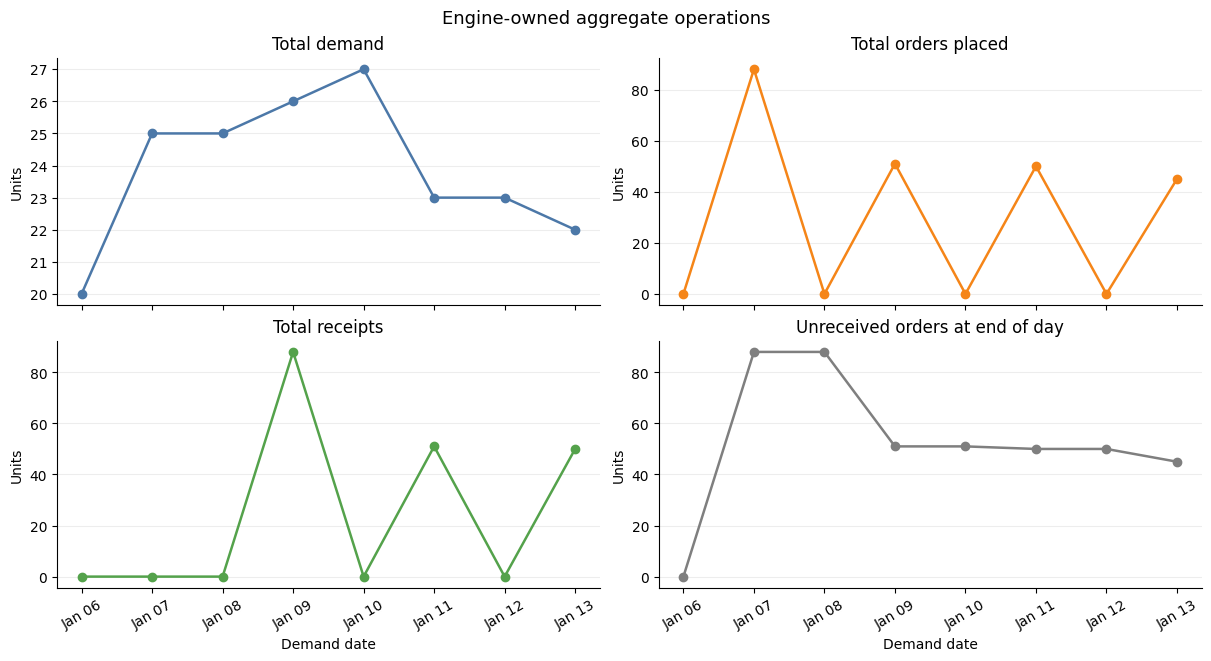

In [21]:
engine_period_events = engine_result.to_event_frame(window='scoring')
engine_period_events = engine_period_events.loc[
    engine_period_events['event_type'].eq('period')
].copy()
engine_portfolio = engine_period_events.groupby(['period', 'date'], as_index=False).agg(
    demand=('demand', 'sum'),
    orders_placed=('order_quantity', 'sum'),
    receipts=('received_units', 'sum'),
    unreceived_orders_end=('on_order_end', 'sum'),
)
operation_panels = [
    ('Total demand', 'demand', '#4C78A8'),
    ('Total orders placed', 'orders_placed', '#F58518'),
    ('Total receipts', 'receipts', '#54A24B'),
    ('Unreceived orders at end of day', 'unreceived_orders_end', '#7F7F7F'),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 6.5), sharex=True, layout='constrained')
for axis, (title, column, color) in zip(axes.flat, operation_panels):
    axis.plot(engine_portfolio['date'], engine_portfolio[column],
              color=color, marker='o', linewidth=1.8)
    axis.set(title=title, ylabel='Units')
    axis.grid(axis='y', alpha=0.22)
    axis.spines[['top', 'right']].set_visible(False)
for axis in axes[1]:
    axis.set_xlabel('Demand date')
    axis.xaxis.set_major_locator(mdates.DayLocator())
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    axis.tick_params(axis='x', labelrotation=30)
fig.suptitle('Engine-owned aggregate operations', fontsize=13)
plt.show()

### Use the engine ledger for canonical metrics

Unlike the caller-owned snapshots, the engine result contains validated event rows. These per-SKU and pooled metrics therefore come from `InventoryEvaluator` with an explicit scoring window and grouping. Zero shortages in this deliberately stocked scenario make fill rate 1.0 for every item; the chart is descriptive, not a policy comparison.

In [22]:
canonical_per_sku = InventoryEvaluator().fit(
    simulation_result=engine_result, window='scoring'
).evaluate(
    metrics=[fill_rate, avg_on_hand, order_units], groupby=['unique_id']
)
canonical_pooled = InventoryEvaluator().fit(
    simulation_result=engine_result, window='scoring'
).evaluate(
    metrics=[fill_rate, avg_on_hand, order_units], groupby=[]
)
print('Canonical per-SKU metrics from engine events')
print(canonical_per_sku.round(3).to_string(index=False))
print('\nCanonical pooled metrics from engine events')
print(canonical_pooled.round(3).to_string(index=False))

Canonical per-SKU metrics from engine events
  unique_id  fill_rate  avg_on_hand  order_units
   tea_250g        1.0       12.750         58.0
coffee_250g        1.0       15.625         51.0
 pasta_500g        1.0       12.500         48.0
cereal_400g        1.0       14.875         45.0
  soup_400g        1.0       12.125         32.0

Canonical pooled metrics from engine events
 fill_rate  avg_on_hand  order_units
       1.0       13.575        234.0


### Compare canonical item-level summary statistics

Separate panels keep the rate and unit measures on honest scales: service is a rate, while average stock and ordered units are quantities.

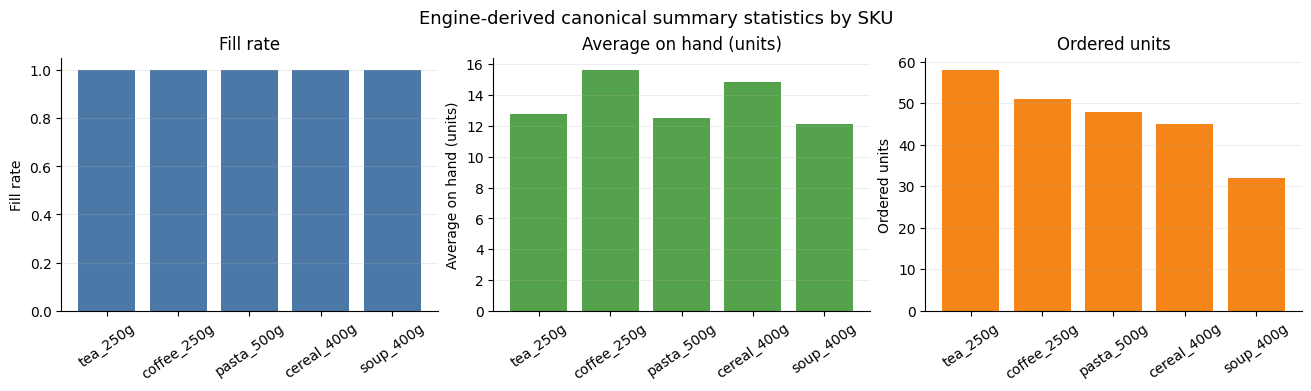

In [23]:
metric_panels = [
    ('fill_rate', 'Fill rate', '#4C78A8'),
    ('avg_on_hand', 'Average on hand (units)', '#54A24B'),
    ('order_units', 'Ordered units', '#F58518'),
]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), layout='constrained')
for axis, (column, label, color) in zip(axes, metric_panels):
    axis.bar(canonical_per_sku['unique_id'], canonical_per_sku[column], color=color)
    axis.set(title=label, ylabel=label)
    axis.tick_params(axis='x', rotation=35)
    axis.grid(axis='y', alpha=0.22)
    axis.spines[['top', 'right']].set_visible(False)
fig.suptitle('Engine-derived canonical summary statistics by SKU', fontsize=13)
plt.show()

### Compare terminal state, not artifact ownership

Under these matched conditions, every SKU ends with the same physical and pipeline state in both paths. This equality does not turn caller snapshots into canonical events or a manifest; it confirms the component transitions only.

In [24]:
terminal_fields = ['unique_id', 'on_hand', 'backorders', 'total_in_transit', 'inventory_position', 'period', 'date']
manual_terminal = manual_state.inventory_position()[terminal_fields].sort_values('unique_id').reset_index(drop=True)
engine_terminal = engine_result.inventory.inventory_position()[terminal_fields].sort_values('unique_id').reset_index(drop=True)
terminal_comparison = manual_terminal.merge(
    engine_terminal, on='unique_id', suffixes=('_manual_loop', '_engine')
)
print(terminal_comparison.to_string(index=False))

for field in terminal_fields[1:]:
    assert manual_terminal[field].equals(engine_terminal[field])
assert engine_result.to_event_frame().shape[0] == len(demand)
print('\nAll five terminal states match the equivalent engine run.')

  unique_id  on_hand_manual_loop  backorders_manual_loop  total_in_transit_manual_loop  inventory_position_manual_loop  period_manual_loop date_manual_loop  on_hand_engine  backorders_engine  total_in_transit_engine  inventory_position_engine  period_engine date_engine
cereal_400g                 18.0                     0.0                          10.0                            28.0                 8.0       2026-01-13            18.0                0.0                     10.0                       28.0            8.0  2026-01-13
coffee_250g                 22.0                     0.0                           9.0                            31.0                 8.0       2026-01-13            22.0                0.0                      9.0                       31.0            8.0  2026-01-13
 pasta_500g                 18.0                     0.0                           9.0                            27.0                 8.0       2026-01-13            18.0                0.0

## Takeaway

A caller-owned component loop is supported for deliberate custom orchestration across complete multi-SKU demand vectors. The caller must preserve its own evidence and provenance. Choose `SimulationEngine` when the work also needs complete preflight, canonical accounting events, callback/constraint audits, evaluator-ready results, and a run manifest.